In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.5.1


In [2]:
import joblib

X_train_seq = joblib.load("X_train_seq.pkl")
y_train_seq = joblib.load("y_train_seq.pkl")
X_val_seq = joblib.load("X_val_seq.pkl")
y_val_seq = joblib.load("y_val_seq.pkl")
X_test_seq = joblib.load("X_test_seq.pkl")
print("Data loaded successfully.")

X_train_seq= torch.cat([X_train_seq['cont'], X_train_seq['survey'], X_train_seq['body'], X_train_seq['time']], dim=-1)
X_val_seq= torch.cat([X_val_seq['cont'], X_val_seq['survey'], X_val_seq['body'], X_val_seq['time']], dim=-1)
X_test_seq = torch.cat([X_test_seq['cont'], X_test_seq['survey'], X_test_seq['body'], X_test_seq['time']], dim=-1)
                       
print(X_train_seq.shape)
print(y_train_seq.shape)
print(X_val_seq.shape)
print(y_val_seq.shape)
print(X_test_seq.shape)

input_shape = X_train_seq.shape[1:]

Data loaded successfully.
torch.Size([5346, 32, 36])
torch.Size([5346])
torch.Size([603, 32, 36])
torch.Size([603])
torch.Size([11916, 32, 36])


In [3]:
from torch.utils.data import TensorDataset

train_ds = TensorDataset(X_train_seq.float(), y_train_seq.long())
val_ds   = TensorDataset(X_val_seq.float(), y_val_seq.long())

In [4]:
import torch.nn as nn

# Hyperparameters

BATCH_SIZE = 512

# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        
HIDDEN_SIZE = 128        

# Regularization
DROPOUT_RATE = 0.2         
L1_LAMBDA = 0            
L2_LAMBDA = 0           

criterion = nn.CrossEntropyLoss()

In [5]:
from utils import make_loader

# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([512, 32, 36])
Labels batch shape: torch.Size([512])


In [6]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [7]:
from classes import RecurrentClassifier

rnn_model = RecurrentClassifier(
    input_size=input_shape[-1],
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=3,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='GRU'
    ).to(device)

x = torch.randn(1, input_shape[0], input_shape[1]).to(device)

optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [8]:
from utils import fit

rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    verbose=10,
    experiment_name="gru",
    patience=PATIENCE
    )

if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.7198, F1=0.6676 | Val: Loss=0.6900, F1=0.6783
Epoch  10/500 | Train: Loss=0.4894, F1=0.7827 | Val: Loss=0.5490, F1=0.7699
Epoch  20/500 | Train: Loss=0.3625, F1=0.8594 | Val: Loss=0.3949, F1=0.8663
Epoch  30/500 | Train: Loss=0.2273, F1=0.9135 | Val: Loss=0.3368, F1=0.8880
Epoch  40/500 | Train: Loss=0.1548, F1=0.9447 | Val: Loss=0.2608, F1=0.9191
Epoch  50/500 | Train: Loss=0.1151, F1=0.9657 | Val: Loss=0.3367, F1=0.8883
Epoch  60/500 | Train: Loss=0.0923, F1=0.9736 | Val: Loss=0.3822, F1=0.9047
Epoch  70/500 | Train: Loss=0.0575, F1=0.9806 | Val: Loss=0.3008, F1=0.9091
Epoch  80/500 | Train: Loss=0.0488, F1=0.9865 | Val: Loss=0.2671, F1=0.9239
Epoch  90/500 | Train: Loss=0.0385, F1=0.9861 | Val: Loss=0.3483, F1=0.9006
Epoch 100/500 | Train: Loss=0.0292, F1=0.9907 | Val: Loss=0.3953, F1=0.8981
Epoch 110/500 | Train: Loss=0.0226, F1=0.9921 | Val: Loss=0.4053, F1=0.9140
Epoch 120/500 | Train: Loss=0.0244, F1=0.9922 | Val: Loss=0.3912,

/Users/edogriba/Desktop/CH01/utils.py:248: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


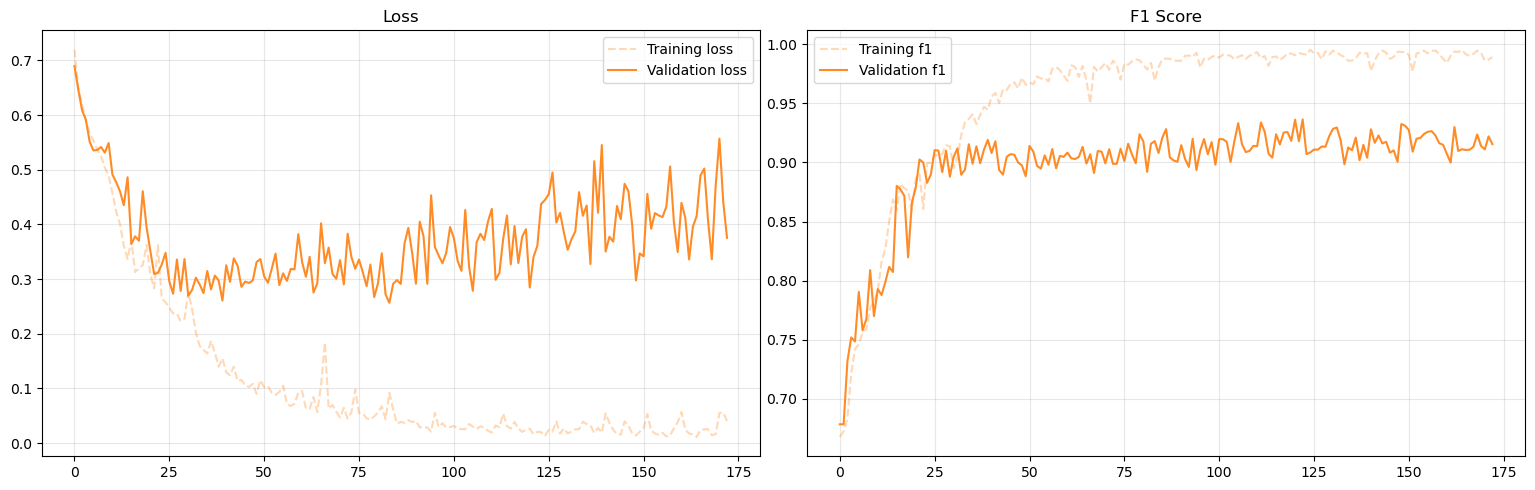

In [9]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first figure
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second figure
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9386
Precision over the validation set: 0.9394
Recall over the validation set: 0.9386
F1 score over the validation set: 0.9365


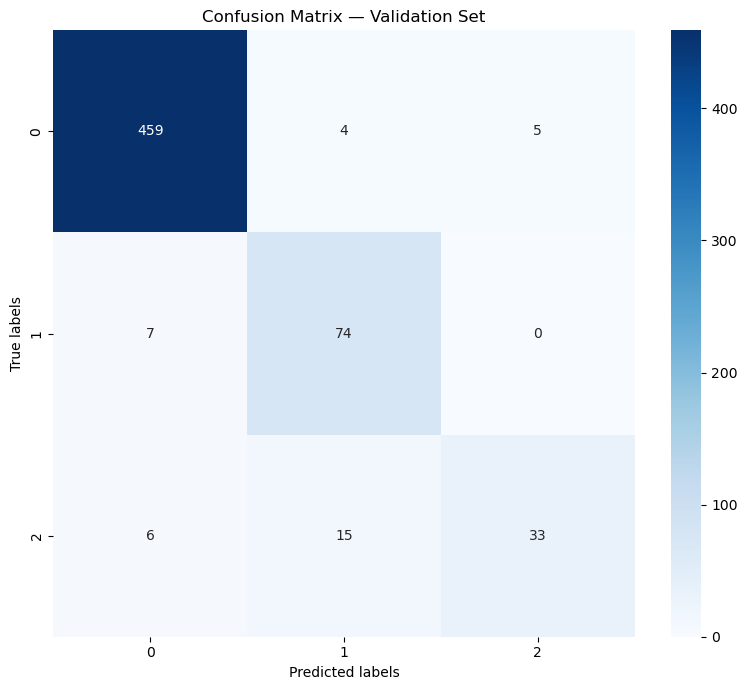

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

val_preds, val_targets = [], []

with torch.no_grad():  
    for xb, yb in val_loader:
        xb = xb.to(device)

        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        val_preds.append(preds)
        val_targets.append(yb.numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

cm = confusion_matrix(val_targets, val_preds)

labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

NUM_TEST_SAMPLES = 1324
BATCH_SIZE = 64

test_ds = TensorDataset(X_test_seq)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

rnn_model.eval()
test_preds = []

with torch.no_grad():
    for (xb,) in tqdm(test_loader, desc="Running inference"):
        xb = xb.to(device)

        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        test_preds.append(preds)

test_preds = np.concatenate(test_preds)
print(f"Raw window-level predictions: {test_preds.shape}")

windows_per_sample = len(test_preds) // NUM_TEST_SAMPLES
assert len(test_preds) % NUM_TEST_SAMPLES == 0, \
    "Prediction count does not divide evenly into NUM_TEST_SAMPLES."

print(f"Windows per sample: {windows_per_sample}")

agg_preds = []
for i in range(NUM_TEST_SAMPLES):
    start = i * windows_per_sample
    end   = (i + 1) * windows_per_sample
    chunk = test_preds[start:end]
    maj   = Counter(chunk).most_common(1)[0][0]
    agg_preds.append(maj)

agg_preds = np.array(agg_preds)
print("Aggregated predictions:", agg_preds.shape)


label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
labels = [label_map[p] for p in agg_preds]

sample_indices = [f"{i:03d}" for i in range(NUM_TEST_SAMPLES)]

submission = pd.DataFrame({
    "sample_index": sample_indices,
    "label": labels
})

submission.to_csv("submission.csv", index=False)

print("Submission file saved as submission.csv")
print("Rows:", len(submission))

Running inference: 100%|██████████| 187/187 [00:07<00:00, 26.19it/s]

Raw window-level predictions: (11916,)
Windows per sample: 9
Aggregated predictions: (1324,)
CNN-GRU submission saved as submission.csv
Rows: 1324
